# Isolation Forest

## Introduction to Anomaly Detection

Anomaly detection, also known as outlier detection, is a data mining technique used to identify rare items, events, or observations that deviate significantly from the majority of the data. These "anomalies" or "outliers" often indicate critical and actionable information, such as credit card fraud, a malfunctioning industrial machine, or a novel disease in medical diagnostics.

### Importance of Anomaly Detection:

*   **Fraud Detection:** Identifying unusual transactions in financial data.
*   **Intrusion Detection:** Spotting abnormal network traffic patterns that might indicate a cyberattack.
*   **Health Monitoring:** Detecting unusual readings from sensors in critical systems (e.g., aircraft engines, patient vital signs).
*   **Manufacturing Quality Control:** Identifying defective products on an assembly line.
*   **Medical Diagnosis:** Recognizing rare disease patterns in patient data.

### Common Approaches in Data Mining:

1.  **Statistical Methods:** Assume a statistical distribution for the normal data and identify data points that fall outside this distribution (e.g., Z-score, Gaussian models).
2.  **Proximity-Based Methods:** Identify anomalies as data points that are isolated from their neighbors or have a low density compared to their surroundings (e.g., K-Nearest Neighbors, Local Outlier Factor).
3.  **Classification-Based Methods:** Train a classifier on labeled data (normal vs. anomalous) to predict the class of new data points. If only normal data is available, one-class classifiers can be used.
4.  **Clustering-Based Methods:** Assume that normal data points belong to large and dense clusters, while anomalies either do not belong to any cluster or form very small clusters.
5.  **Tree-Based Methods:** Utilize tree structures to isolate anomalies, often by partitioning the data space (e.g., Isolation Forest).

## Introduction to Isolation Forest

Isolation Forest is an unsupervised learning algorithm that belongs to the tree-based anomaly detection methods. It works on the principle that anomalies are "few and different" and therefore are more susceptible to isolation than normal points.

### How it Isolates Anomalies Using Random Partitioning:

The core idea behind Isolation Forest is to randomly select a feature and then randomly select a split value between the minimum and maximum values of that feature. This process recursively partitions the data space. Anomalies, being fewer and having distinct feature values, are typically isolated in fewer splits compared to normal data points, which require more splits to be separated.

### Intuition Behind Isolation Trees:

Imagine you have a dataset with a few outliers. If you randomly draw a line (or hyperplane in higher dimensions) to cut the data, an outlier is much more likely to be separated from the rest of the data by just a few cuts. Normal data points, being part of a dense cluster, will require many more cuts to be fully isolated from their neighbors. Each such random partitioning process creates an 'isolation tree'.

### Step-by-Step Breakdown of the Algorithm:

1.  **Build Multiple Isolation Trees:** The algorithm constructs an ensemble of isolation trees (iTrees). For each tree:
    *   A subsample of the training data is recursively partitioned.
    *   At each node, a feature is randomly selected, and a random split value for that feature is chosen between the minimum and maximum values of the selected feature in the current data subset.
    *   This partitioning continues until either the node contains only one instance, all instances in the node have the same values for all features, or a maximum tree depth is reached.
2.  **Anomaly Scoring:** Once the ensemble of iTrees is built, an anomaly score is calculated for each data point.
    *   For a given data point, traverse each iTree from the root until it reaches a leaf node.
    *   The path length (number of edges) from the root to the terminating node is recorded for each data point in each tree.
    *   Anomalies typically have shorter path lengths because they are easier to isolate.
    *   The anomaly score is then derived from the average path length across all iTrees. A higher score indicates a higher likelihood of being an anomaly.
3.  **Thresholding:** A threshold is then applied to these anomaly scores to classify data points as either normal or anomalous. This threshold is often determined by a `contamination` parameter, which specifies the expected proportion of anomalies in the dataset.

## Generate Synthetic Data with Anomalies

To effectively illustrate the Isolation Forest algorithm, we will create a synthetic dataset. This dataset will consist of a large cluster of 'normal' data points and a few 'anomalous' data points that are clearly separated from the normal cluster. We'll use `numpy` for numerical operations and `matplotlib` for basic visualization.

Total data points: 405
Number of normal data points: 400
Number of anomalous data points: 5


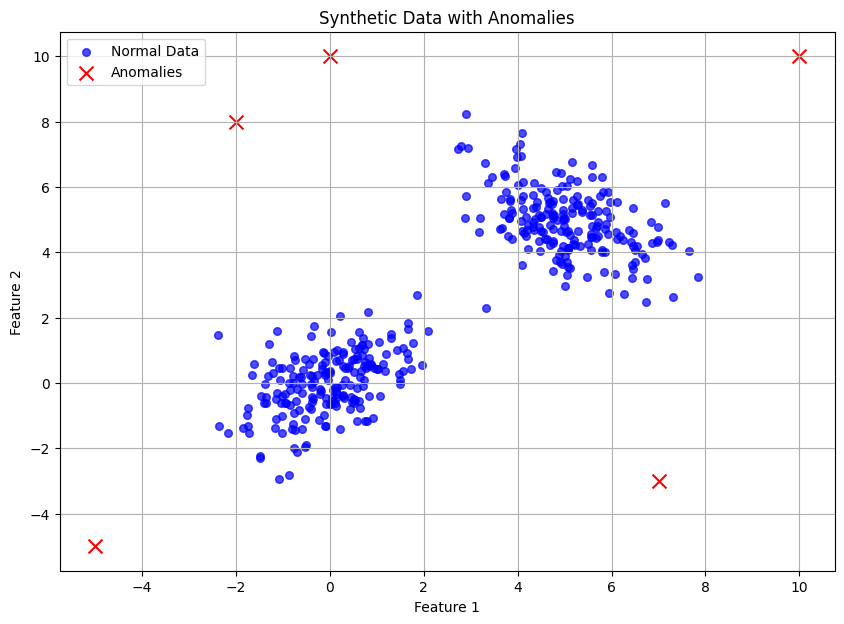

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Generate normal data points
# Two clusters of normal data
mean1 = [0, 0]
cov1 = [[1, 0.5], [0.5, 1]]
normal_data1 = np.random.multivariate_normal(mean1, cov1, 200)

mean2 = [5, 5]
cov2 = [[1, -0.5], [-0.5, 1]]
normal_data2 = np.random.multivariate_normal(mean2, cov2, 200)

normal_data = np.vstack([normal_data1, normal_data2])

# Generate anomalous data points (outliers)
anomalies = np.array([
    [-5, -5],
    [10, 10],
    [-2, 8],
    [7, -3],
    [0, 10]
])

# Combine normal data and anomalies
X = np.vstack([normal_data, anomalies])

# Create labels: 0 for normal, 1 for anomaly
y = np.array([0] * len(normal_data) + [1] * len(anomalies))

print(f"Total data points: {len(X)}")
print(f"Number of normal data points: {len(normal_data)}")
print(f"Number of anomalous data points: {len(anomalies)}")

# Visualize the synthetic data
plt.figure(figsize=(10, 7))
plt.scatter(normal_data[:, 0], normal_data[:, 1], c='blue', label='Normal Data', s=30, alpha=0.7)
plt.scatter(anomalies[:, 0], anomalies[:, 1], c='red', marker='x', s=100, label='Anomalies')
plt.title('Synthetic Data with Anomalies')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()


## Interactive Animation: Partitioning Space"
Use the slider below to add random splits. Notice how anomalies get isolated in their own rectangular regions much earlier (with fewer splits) than points in the dense normal clusters.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown


# Generate a fixed set of random splits to ensure the animation is consistent
np.random.seed(100)
max_splits = 40
splits = []
for _ in range(max_splits):
    feature = np.random.choice([0, 1])
    # Random split between min and max of that feature
    split_val = np.random.uniform(X[:, feature].min(), X[:, feature].max())
    splits.append((feature, split_val))

def update_plot(num_splits):
    plt.figure(figsize=(10, 8))
    # Plot normal data
    plt.scatter(normal_data[:, 0], normal_data[:, 1], c='blue', label='Normal Data', s=30, alpha=0.5)
    # Plot anomalies
    plt.scatter(anomalies[:, 0], anomalies[:, 1], c='red', marker='X', s=100, label='Anomalies')

    # Draw the split lines
    for i in range(num_splits):
        feat, val = splits[i]
        if feat == 0:
            plt.axvline(x=val, color='green', linestyle='-', alpha=0.6, linewidth=2)
        else:
            plt.axhline(y=val, color='orange', linestyle='-', alpha=0.6, linewidth=2)

    plt.title(f'Interactive Isolation Tree Building: {num_splits} Splits')
    plt.xlim(X[:, 0].min() - 1, X[:, 0].max() + 1)
    plt.ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(False)
    plt.show()

# Create an interactive slider
step_slider = widgets.IntSlider(value=0, min=0, max=max_splits, step=1,
                                description='Number of Splits:', style={'description_width': 'initial'})
widgets.interact(update_plot, num_splits=step_slider);

interactive(children=(IntSlider(value=0, description='Number of Splits:', max=40, style=SliderStyle(descriptio…

## Apply Isolation Forest

We will now implement the Isolation Forest algorithm using `scikit-learn` on our synthetic dataset. A crucial parameter for Isolation Forest is `contamination`, which represents the proportion of outliers in the dataset. Since we synthetically created our data, we know the exact proportion of anomalies, which we can use to set this parameter accurately.

In [3]:
from sklearn.ensemble import IsolationForest

# Calculate the contamination rate
# Number of anomalies = 5, Total data points = 405
contamination_rate = len(anomalies) / len(X)
print(f"Calculated contamination rate: {contamination_rate:.4f}")

# Initialize the Isolation Forest model
# n_estimators: The number of base estimators (trees) in the ensemble.
# max_samples: The number of samples to draw from X to train each base estimator.
# contamination: The amount of contamination of the dataset, i.e., the proportion of outliers in the dataset.
# random_state: Controls the pseudo random number generation for reproducibility.
model = IsolationForest(n_estimators=100, max_samples='auto', contamination=contamination_rate, random_state=42)

# Fit the model to the data
model.fit(X)

# Predict the anomaly labels (-1 for outliers, 1 for inliers)
predictions = model.predict(X)

# Get anomaly scores (lower score indicates higher likelihood of anomaly)
anomaly_scores = model.decision_function(X)

print(f"First 10 predictions: {predictions[:10]}")
print(f"First 10 anomaly scores: {anomaly_scores[:10]}")

# Add predictions and anomaly scores to our original data for easier analysis
X_with_preds = np.hstack([X, predictions.reshape(-1, 1), anomaly_scores.reshape(-1, 1)])

# Separate normal and anomalous points based on Isolation Forest predictions
detected_anomalies = X_with_preds[X_with_preds[:, 2] == -1]
detected_normal = X_with_preds[X_with_preds[:, 2] == 1]

print(f"Number of detected anomalies by Isolation Forest: {len(detected_anomalies)}")

Calculated contamination rate: 0.0123
First 10 predictions: [1 1 1 1 1 1 1 1 1 1]
First 10 anomaly scores: [0.22375411 0.1795604  0.23501248 0.1101198  0.22799975 0.22828821
 0.15201442 0.12840327 0.21012426 0.16332914]
Number of detected anomalies by Isolation Forest: 5


### How the `predict` function uses anomaly scores and thresholds:

The `predict` function in `sklearn.ensemble.IsolationForest` classifies data points as either anomalies or normal based on a threshold applied to the anomaly scores. Here's a breakdown:

1.  **Anomaly Scores:** The `decision_function` method (which `predict` internally relies on) calculates an anomaly score for each data point. These scores are derived from the average path length required to isolate a point in the isolation trees. A *lower* score indicates a *higher* likelihood of being an anomaly, as anomalies are typically easier to isolate, resulting in shorter path lengths.

2.  **Contamination Parameter:** The `contamination` hyperparameter, set during model initialization (e.g., `IsolationForest(..., contamination=contamination_rate, ...)`), is crucial. It specifies the expected proportion of anomalies within the dataset.

3.  **Threshold Determination:** The `predict` function implicitly determines a threshold on the anomaly scores based on this `contamination` rate. It effectively ranks all data points by their anomaly scores and then sets the threshold such that the top `contamination * total_number_of_samples` data points (i.i., those with the lowest anomaly scores, indicating highest anomaly likelihood) are classified as outliers.

4.  **Classification:**
    *   Data points with an anomaly score **below** this determined threshold are classified as **anomalies** (assigned a label of -1).
    *   Data points with an anomaly score **above or equal to** this threshold are classified as **normal** (assigned a label of 1).

In essence, while you don't manually set a numerical threshold for `predict`, the `contamination` parameter provides the model with the necessary information to automatically establish this threshold and make its classifications.

## Visualize Anomaly Detection Results

To effectively understand the performance of the Isolation Forest model, we will visualize the dataset again. This time, we will highlight the data points classified as anomalies by the model, distinguishing them from the normal data points. This visualization will help us observe if the model successfully identified our synthetically introduced outliers.

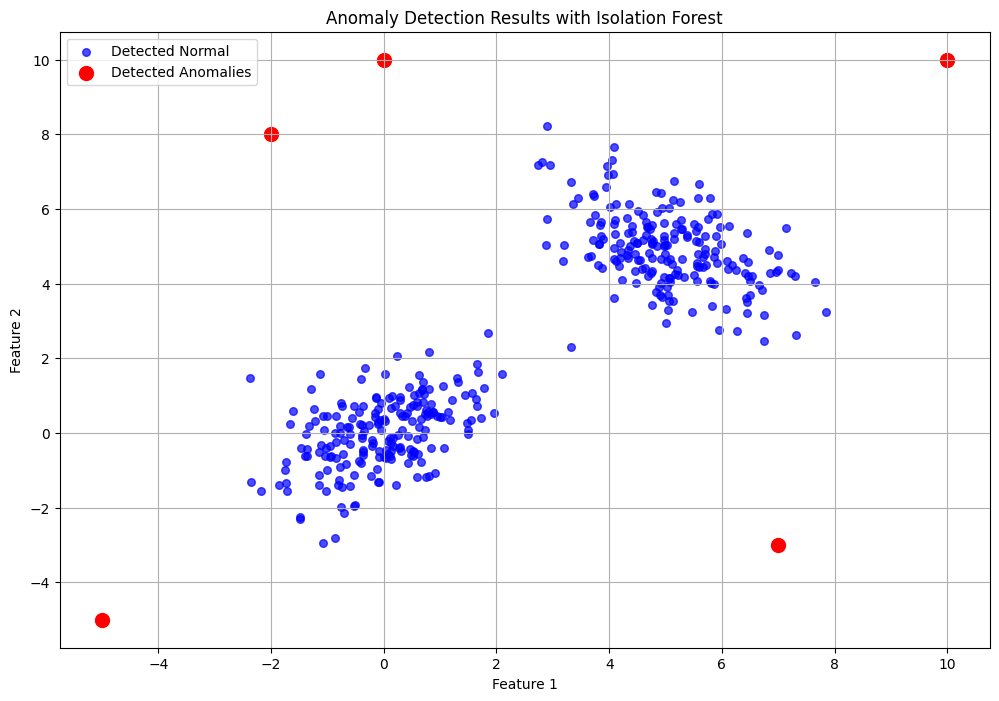

In [ ]:
plt.figure(figsize=(12, 8))

# Plot normal points
plt.scatter(detected_normal[:, 0], detected_normal[:, 1],
            c='blue', label='Detected Normal', s=30, alpha=0.7)

# Plot detected anomalies
plt.scatter(detected_anomalies[:, 0], detected_anomalies[:, 1],
            c='red', marker='o', s=100, label='Detected Anomalies')

plt.title('Anomaly Detection Results with Isolation Forest')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

## Explain Key Hyperparameters

The performance and behavior of the Isolation Forest algorithm are heavily influenced by its hyperparameters. Understanding these parameters is crucial for effectively applying the model to different datasets.

### 1. `n_estimators`

*   **Description:** This parameter specifies the number of individual isolation trees (iTrees) to build in the ensemble. An Isolation Forest is an ensemble method, meaning it combines the results of multiple decision trees.
*   **Impact:**
    *   **Higher `n_estimators`:** Generally leads to a more robust and stable model as it reduces the impact of randomness from individual trees. The anomaly scores become more reliable. However, it also increases training and prediction time.
    *   **Lower `n_estimators`:** The model might be less stable and more sensitive to the random subsampling and feature selection. There's a risk of underfitting if the number is too low.
*   **Recommendation:** A common practice is to start with a value like 100 or 200. Increasing it further often yields diminishing returns in accuracy but linearly increases computation.

### 2. `max_samples`

*   **Description:** This parameter controls the number of samples to draw from the training data to build each individual isolation tree. It can be an integer (absolute number of samples) or a float (proportion of the total samples).
*   **Impact:**
    *   **Smaller `max_samples`:** Increases the efficiency of the algorithm, as each tree is built on a smaller subset. It also helps in isolating anomalies faster since normal points in dense clusters require more partitions to be separated in a small sample.
    *   **Larger `max_samples`:** Can make it harder to isolate anomalies, especially if the sample size approaches the full dataset, as more splits would be needed. This might also increase computation time.
*   **Recommendation:** The default value is `'auto'`, which effectively means `min(256, n_samples)`. For datasets with a very small number of true anomalies, a smaller `max_samples` can be beneficial. For very large datasets, a fixed smaller number like 256 or 512 is often sufficient and computationally efficient.

### 3. `contamination`

*   **Description:** This is arguably the most critical parameter for Isolation Forest in a practical setting. It represents the proportion of outliers in the dataset, a value between 0.0 and 0.5. The model uses this parameter to determine the decision threshold for classifying points as anomalous or normal.
*   **Impact:**
    *   **Higher `contamination`:** The model will classify a larger number of data points as anomalies.
    *   **Lower `contamination`:** The model will be more conservative and classify fewer data points as anomalies.
*   **Recommendation:**
    *   **Known Contamination:** If the actual percentage of anomalies in your dataset is known or can be estimated (as in our synthetic example), set `contamination` to that value. This leads to the most accurate thresholding.
    *   **Unknown Contamination:** If the contamination rate is unknown, it often requires domain expertise or experimentation. You might need to try different values and evaluate the results based on business requirements or external validation methods.
*   **Note:** This parameter does not affect the tree building or anomaly scoring process; it only influences the final classification (whether a point is labeled -1 or 1) by setting a threshold on the anomaly scores.

## Advantages and Disadvantages of Isolation Forest

Like any algorithm, Isolation Forest has its strengths and weaknesses when compared to other anomaly detection techniques.

### Advantages:

*   **Efficiency:** Isolation Forest is highly efficient, especially for large datasets. Its partitioning approach means it doesn't need to compute distance or density metrics for every data point, which can be computationally expensive for other methods (e.g., DBSCAN, Local Outlier Factor).
*   **Scalability:** It scales well to high-dimensional data as it works by isolating anomalies based on individual features rather than relying on distance calculations in a high-dimensional space.
*   **Low Memory Requirement:** Each tree is built on a subsample of the data, and it only stores the split points and feature indices, leading to lower memory consumption.
*   **Effective for Global Anomalies:** It is particularly effective at detecting global anomalies (points far away from all other data points).
*   **Less Sensitive to Swamping/Masking:** Unlike some distance-based methods, Isolation Forest is less susceptible to 'swamping' (normal points being incorrectly labeled as anomalies) or 'masking' (anomalies being hidden by a large number of normal points).

### Disadvantages:

*   **Difficulty with Local Anomalies:** While good at global anomalies, it may struggle with 'local anomalies' – points that are anomalous with respect to their local neighborhood but not necessarily globally.
*   **Parameter Sensitivity (`contamination`):** The `contamination` parameter is crucial and often difficult to set accurately if the true proportion of anomalies is unknown. Misestimating it can lead to either too many false positives or missing true anomalies.
*   **Not Ideal for Anomaly Clusters:** If anomalies form dense clusters themselves, Isolation Forest might have difficulty isolating them quickly, as they would require more splits to separate from each other.
*   **Doesn't Provide Anomaly 'Reason':** It identifies anomalies but doesn't inherently explain *why* a particular point is anomalous beyond its short path length in the trees.
*   **Data Type Limitation:** Primarily designed for numerical data. Handling categorical features requires pre-processing.
*   **Randomness:** Due to its random nature in feature and split point selection, results can vary slightly between runs if `random_state` is not fixed, although ensemble averaging mitigates this to a large extent.

## Case Study: Credit Card Fraud Detection

Let's apply both Isolation Forest (unsupervised) and a Decision Tree (supervised) to a real-world dataset: The Credit Card Fraud Detection dataset from OpenML. This dataset is highly imbalanced, making it a perfect candidate for anomaly detection.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("Fetching the Credit Card Fraud dataset from OpenML... (This might take a minute)")
# Fetch dataset
credit_data = fetch_openml(name='creditcard', version=1, as_frame=True, parser='auto')
df_credit = credit_data.frame

# The target class is 'Class', mostly '0' (normal) or '1' (fraud)
df_credit['Class'] = df_credit['Class'].astype(int)

print(f"\nDataset Shape: {df_credit.shape}")
print("\nClass Distribution (Normal = 0, Fraud = 1):")
print(df_credit['Class'].value_counts())

Fetching the Credit Card Fraud dataset from OpenML... (This might take a minute)

Dataset Shape: (284807, 30)

Class Distribution (Normal = 0, Fraud = 1):
Class
0    284315
1       492
Name: count, dtype: int64


In [22]:
df_credit.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Dataset Features Description

The features in this Credit Card Fraud dataset are unique due to privacy reasons. Here is a breakdown:

*   **`V1` through `V28`**: These are numerical features resulting from a PCA (Principal Component Analysis) transformation. To protect user confidentiality, the original features (which might have represented user location, purchase category, time, etc.) were transformed, and their true meanings are hidden.
*   **`Amount`**: The actual transaction amount.
*   **`Class`**: The target variable (label). It takes the value `1` for fraudulent transactions and `0` for normal transactions.

### Train and Evaluate Models

We will split the data into training and testing sets. We will train both models and compare their metrics. Note that Isolation Forest will only use the feature data for "training" (as it is unsupervised), while the Decision Tree will use both the features and the target labels.

In [19]:
# Prepare the data
X_credit = df_credit.drop('Class', axis=1)
y_credit = df_credit['Class']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_credit, y_credit, test_size=0.2, random_state=42, stratify=y_credit
)

print("--- Training Isolation Forest (Unsupervised) ---")
# Calculate contamination for Isolation Forest (proportion of anomalies in train set)
contamination_rate = y_train.mean()
iso_forest = IsolationForest(n_estimators=100, contamination=contamination_rate, random_state=42)
iso_forest.fit(X_train)

# Predict and map (-1 for anomaly, 1 for normal -> 1 for fraud, 0 for normal)
iso_preds = iso_forest.predict(X_test)
iso_preds_mapped = np.where(iso_preds == -1, 1, 0)

print("\n--- Training Decision Tree (Supervised) ---")
dt_classifier = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_classifier.fit(X_train, y_train)
dt_preds = dt_classifier.predict(X_test)

print("\nModel Training Complete.")

--- Training Isolation Forest (Unsupervised) ---

--- Training Decision Tree (Supervised) ---

Model Training Complete.


=== ISOLATION FOREST RESULTS ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.32      0.33      0.32        98

    accuracy                           1.00     56962
   macro avg       0.66      0.66      0.66     56962
weighted avg       1.00      1.00      1.00     56962


=== DECISION TREE RESULTS ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.79      0.84        98

    accuracy                           1.00     56962
   macro avg       0.95      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962



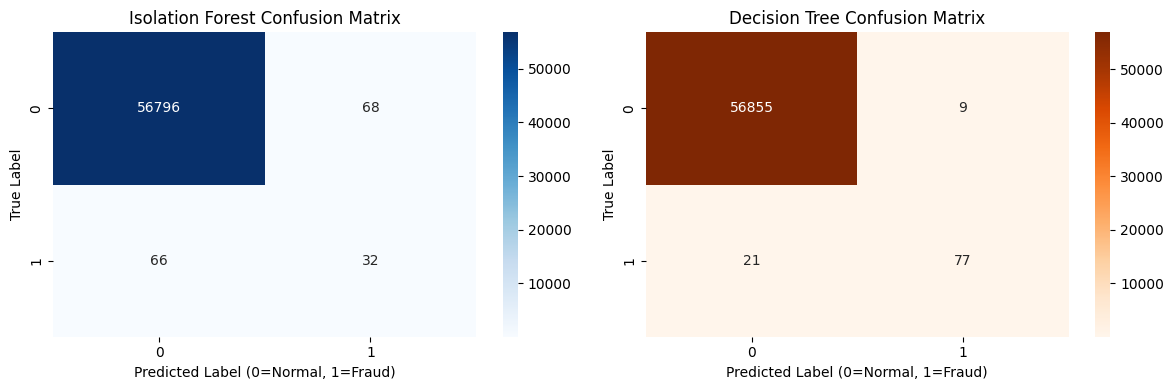

In [20]:
print("=== ISOLATION FOREST RESULTS ===")
print(classification_report(y_test, iso_preds_mapped))

print("\n=== DECISION TREE RESULTS ===")
print(classification_report(y_test, dt_preds))

# Confusion Matrices Comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(confusion_matrix(y_test, iso_preds_mapped), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Isolation Forest Confusion Matrix')
axes[0].set_xlabel('Predicted Label (0=Normal, 1=Fraud)')
axes[0].set_ylabel('True Label')

sns.heatmap(confusion_matrix(y_test, dt_preds), annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title('Decision Tree Confusion Matrix')
axes[1].set_xlabel('Predicted Label (0=Normal, 1=Fraud)')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

### Why did the Decision Tree perform better?

The stark difference in performance comes down to one key factor: **Supervised vs. Unsupervised Learning**.

1. **Access to the "Answers" (Labels):**
   * The **Decision Tree** is a *supervised* model. During training, we gave it both the transaction details (features) AND the actual labels (whether it was fraud or not). It used these labels to actively learn the exact patterns, rules, and thresholds that distinguish a fraudulent transaction from a normal one.
   * The **Isolation Forest**, on the other hand, is an *unsupervised* model. It was completely "blind" to the labels during training. It had to figure out what an anomaly was purely based on the structure of the data—specifically, how easy it is to isolate a point randomly.

2. **Nature of Fraud vs. Pure Anomalies:**
   * Isolation Forest assumes that anomalies are "few and different" (global outliers). However, in credit card fraud, a fraudulent transaction might not look like a massive, obvious outlier in every dimension. It might just look like a slightly unusual combination of otherwise normal behaviors (a local outlier).
   * Because the Decision Tree knows exactly which points are fraud, it can carve out highly specific, complex rules to find them, even if they are "hiding" somewhat close to normal data points.

**Takeaway:** If you have a massive dataset with high-quality, accurate labels for every single data point, a supervised model (like a Decision Tree) will almost always win. Unsupervised methods like Isolation Forest shine when you *don't* have those labels, which is a very common and difficult scenario in real-world fraud detection!

## Handling Categorical Data in Anomaly Detection

When dealing with categorical data in anomaly detection, standard techniques like One-Hot Encoding can be problematic. Here is why and what you should consider instead:

### 1. The Problem with One-Hot Encoding
*   **Sparsity & Dimensionality:** One-hot encoding creates many sparse (mostly zero) columns. Distance-based anomaly detectors struggle with high-dimensional data (the Curse of Dimensionality).
*   **Tree-Based Models:** For algorithms like Isolation Forest that randomly select features to split, having many mostly-zero columns means the model has a high chance of repeatedly picking uninformative features. This reduces its efficiency at isolating true anomalies.

### 2. Best Practice: Frequency / Count Encoding
Instead of expanding dimensions, replace the category with the number of times it appears in the dataset (or its relative frequency).
*   **Why it works for anomalies:** Anomalies are often associated with rare categories. Frequency encoding naturally transforms these rare categories into small numerical values. This distinctly separates them from normal, high-frequency data points, making them extremely easy for algorithms to spot and isolate.

### 3. Target Encoding (Supervised Settings)
If you have labels (like in our supervised Decision Tree example), you can use Target Encoding. This involves replacing the category with the average rate of anomalies for that category. *Caution:* You must use proper out-of-fold techniques to prevent data leakage during training.

### 4. Specialized Algorithms
If your dataset is highly categorical, consider using variations of algorithms explicitly designed for it, such as **Categorical Isolation Forest (CatForest)** or **CBLOF** (Cluster-Based Local Outlier Factor).

## Exercises

Test your understanding of Isolation Forests and anomaly detection with the following exercises.

### Exercise 1: Core Concepts
**Question:** What is the fundamental assumption about anomalies that the Isolation Forest algorithm relies on to effectively detect them?

<details>
<summary><b>Click to see Answer</b></summary>

**Answer:** Isolation Forest assumes that anomalies are **"few and different"**. Because they are rare and have feature values that differ significantly from normal data points, they are easier to separate from the rest of the data. Consequently, they require fewer random partitions (shorter path lengths in the trees) to be isolated compared to dense, normal data points.
</details>

### Exercise 2: Supervised vs. Unsupervised
**Question:** In our credit card fraud scenario, we had labeled data. Why did the Decision Tree (supervised) outperform the Isolation Forest (unsupervised) in finding fraudulent transactions?

<details>
<summary><b>Click to see Answer</b></summary>

**Answer:** A Decision Tree is a supervised model, meaning it uses the provided labels to actively learn the exact patterns and complex rules that distinguish normal from fraudulent behavior. It can find "local anomalies" that don't look dramatically different globally but are fraud based on specific feature interactions.
Isolation Forest is unsupervised and relies purely on the structural isolation of data points. If fraudulent transactions are designed to mimic normal transactions (hiding in dense clusters), Isolation Forest will struggle to separate them quickly.
</details>

### Exercise 3: Setting the Contamination Parameter (Calculation)
**Question:** Suppose you are tasked with setting up an Isolation Forest for a server log dataset containing 25,000 entries. Based on historical audits, you know that roughly `0.15%` of server logs represent malicious network activity.
1. What value should you set for the `contamination` parameter?
2. Exactly how many data points will the `IsolationForest.predict()` function flag as anomalies?

<details>
<summary><b>Click to see Answer</b></summary>

**Answer:**
1. **Contamination value:** The parameter expects a proportion (a decimal), not a percentage.
   `0.15% = 0.15 / 100 = 0.0015`.
   You should set `contamination=0.0015`.
2. **Anomalies flagged:** The model determines the threshold to flag the top `contamination` proportion of the dataset.
   `25,000 total points * 0.0015 contamination rate = 37.5`.
   Since it cannot flag half a point, the model will typically classify the **37** or **38** data points with the lowest anomaly scores as anomalies.
</details>

### Exercise 4: Evaluating Performance (Calculation)
**Question:** You run an Isolation Forest on a dataset of 2,000 points with `contamination=0.04`.
The model flags a certain number of points as anomalies. Later, a domain expert reviews the entire dataset and confirms there are exactly **60 true anomalies** in total.
Upon comparing the model's predictions to the expert's true labels, you find that **45** of the points the model flagged were indeed true anomalies.

Calculate the **Precision** and **Recall** of your Isolation Forest model for the anomaly class.

<details>
<summary><b>Click to see Answer</b></summary>

**Answer:**
First, figure out how many points the model flagged (Predicted Positives):
*   `Total Flagged = 2000 * 0.04 = 80 points`

Now, define the confusion matrix components for anomalies:
*   **True Positives (TP)** = 45 (Points the model flagged that are actually anomalies)
*   **False Positives (FP)** = Total Flagged - TP = 80 - 45 = 35 (Points the model flagged incorrectly)
*   **Actual Positives** = 60 (Total true anomalies in the dataset)

**Calculations:**
*   **Precision** = `TP / (TP + FP)` = `45 / 80` = **0.5625** (or 56.25%).
    *(Meaning: When the model cries "anomaly!", it is right about 56% of the time.)*
*   **Recall** = `TP / Actual Positives` = `45 / 60` = **0.75** (or 75.0%).
    *(Meaning: Out of all the real anomalies that existed, the model successfully caught 75% of them.)*
</details>

### Exercise 5: Data Preprocessing
**Question:** You are analyzing web traffic and have a feature called "Browser Type" (e.g., Chrome, Safari, CustomBot_v1). You decide to use standard One-Hot Encoding, which expands this single feature into 100 new, mostly empty (sparse) columns.
Why is this highly detrimental to the performance of an Isolation Forest, and what is a recommended alternative?

<details>
<summary><b>Click to see Answer</b></summary>

**Answer:** One-Hot Encoding creates a high-dimensional, highly sparse dataset. Because Isolation Forest builds trees by *randomly* selecting features to split on, the algorithm will frequently pick these uninformative, mostly-zero columns. This makes the trees extremely inefficient and requires many more splits to isolate anything, destroying the algorithm's ability to easily spot anomalies.

**Alternative:** A much better approach is **Frequency (or Count) Encoding**. You replace the browser name with the number of times it appears in the dataset. Common browsers get high numbers, while rare bots (like "CustomBot_v1") get very low numbers, making them distinctly stand out numerically, which the Isolation Forest can easily isolate.
</details>